In [122]:
# Pobranie repozytorium projektu z GitHub
!git clone https://github.com/MEGMON19/facerecogniction.git

fatal: destination path 'facerecogniction' already exists and is not an empty directory.


In [123]:
!cd facerecogniction

In [124]:
!ls

augmentation.py				Train_vs_Test_before_split.png
augmentation_replacing_orig.py		viz_1_angry_samples.png
dataset_check_and_split.py		viz_1_disgust_samples.png
datasets				viz_1_fear_samples.png
facerecogniction			viz_1_happy_samples.png
images_generator.py			viz_1_neutral_samples.png
oversampling.py				viz_1_sad_samples.png
readme.md				viz_1_surprise_samples.png
requirements.txt			viz_2_class_distribution.png
stage2					viz_3_augmentation_examples.png
tomek_cnn_5_oversampling.py		yolov8n.pt
Train_Test_Validation_distribution.png


In [125]:
!ls stage2

Etap2_Notebook.ipynb  Etap2_Report.docx  models  README.md


In [126]:
!ls stage2/models

cnn_label_smoothing.keras  mobilenet_finetuned_final.keras


In [127]:
# Import biblioteki TensorFlow i wczytanie modelu klasyfikacji emocji z etapu 2
import tensorflow as tf

# Ścieżka do wytrenowanego modelu CNN
model_path = "stage2/models/cnn_label_smoothing.keras"

emotion_model = tf.keras.models.load_model(model_path)

print("Model wczytany poprawnie")
emotion_model.summary()

Model wczytany poprawnie


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,942,999 (11.23 MB)

 Trainable params: 980,679 (3.74 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 1,961,360 (7.48 MB)

In [128]:
# Instalacja bibliotek potrzebnych do detekcji twarzy (YOLO i OpenCV)
!pip install ultralytics opencv-python-headless

In [129]:
# Wczytanie modelu YOLO do detekcji twarzy
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")
print("YOLO wczytany poprawnie")

YOLO wczytany poprawnie



image 1/1 /content/facerecogniction/facerecogniction/facerecogniction/viz_1_happy_samples.png: 160x640 4 persons, 114.3ms
Speed: 2.0ms preprocess, 114.3ms inference, 1.5ms postprocess per image at shape (1, 3, 160, 640)


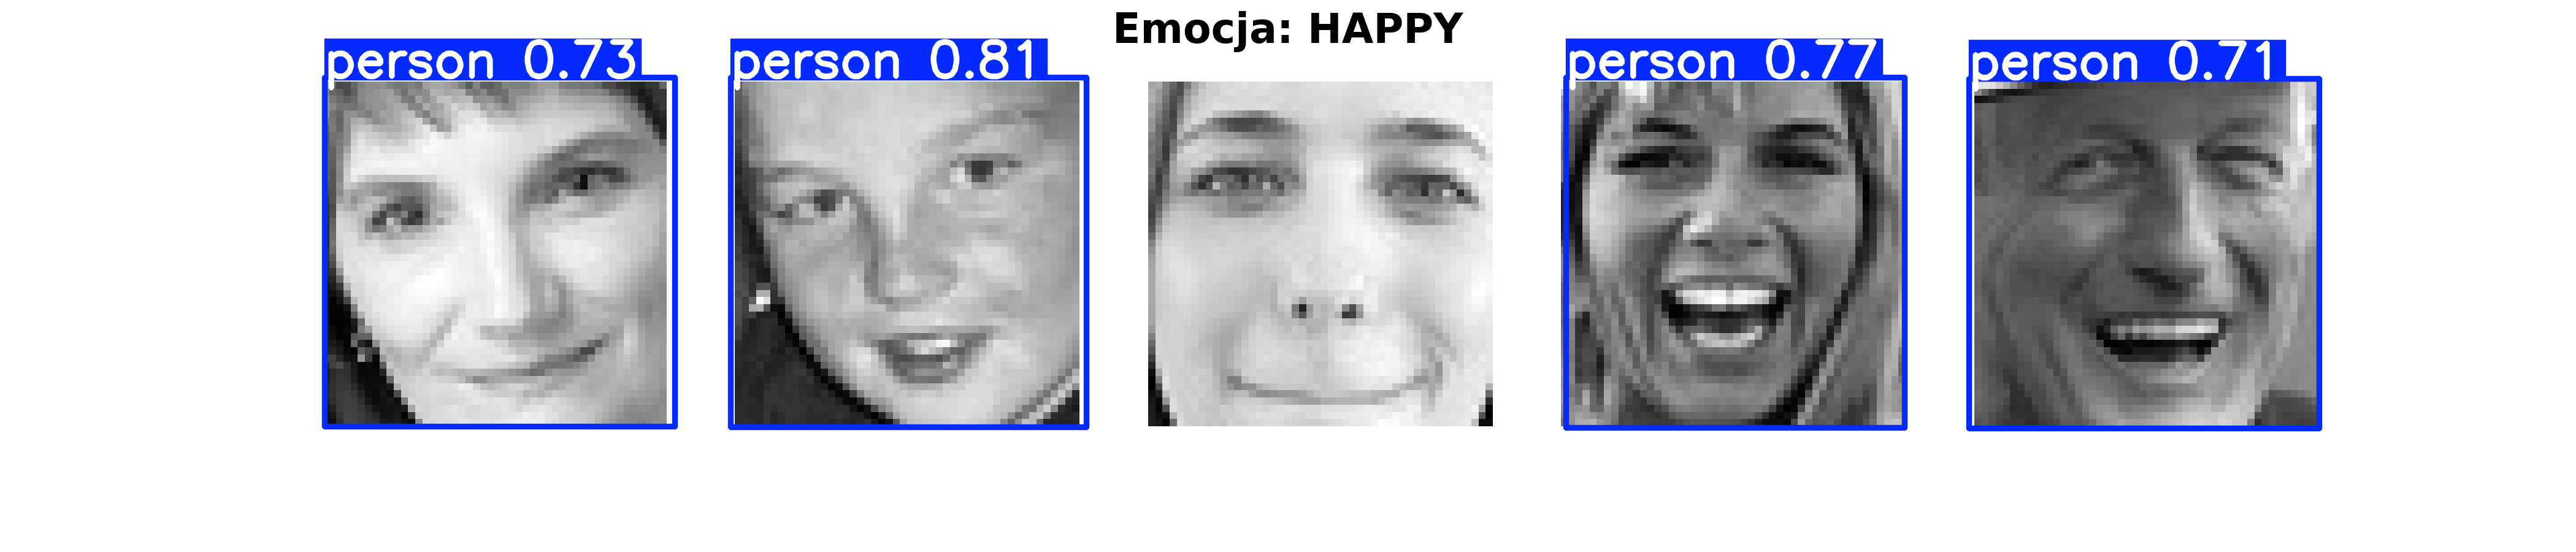

In [130]:
results = yolo_model("viz_1_happy_samples.png")

results[0].show()

In [131]:
import cv2
import numpy as np

# Detekcja twarzy na obrazie oraz przygotowanie obrazu do klasyfikacji emocji
img = cv2.imread("viz_1_happy_samples.png")

results = yolo_model(img)

boxes = results[0].boxes.xyxy.cpu().numpy()

for box in boxes:

    x1, y1, x2, y2 = map(int, box)

# Wycięcie fragmentu obrazu zawierającego twarz
    face = img[y1:y2, x1:x2]

# Konwersja do skali szarości i zmiana rozmiaru obrazu do 48x48
    face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

    face_resized = cv2.resize(face_gray, (48,48))

# Normalizacja wartości pikseli do zakresu 0-1
    face_normalized = face_resized / 255.0

    face_input = np.expand_dims(face_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

# Predykcja emocji przy użyciu modelu CNN
    prediction = emotion_model.predict(face_input)

    emotion_id = np.argmax(prediction)

# Lista klas emocji zwracanych przez model
    emotions = ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]

    print("Predicted emotion:", emotions[emotion_id])


0: 160x640 4 persons, 67.5ms
Speed: 1.9ms preprocess, 67.5ms inference, 1.0ms postprocess per image at shape (1, 3, 160, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted emotion: Happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted emotion: Happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Predicted emotion: Happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Predicted emotion: Happy



0: 160x640 4 persons, 231.4ms
Speed: 8.4ms preprocess, 231.4ms inference, 3.7ms postprocess per image at shape (1, 3, 160, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


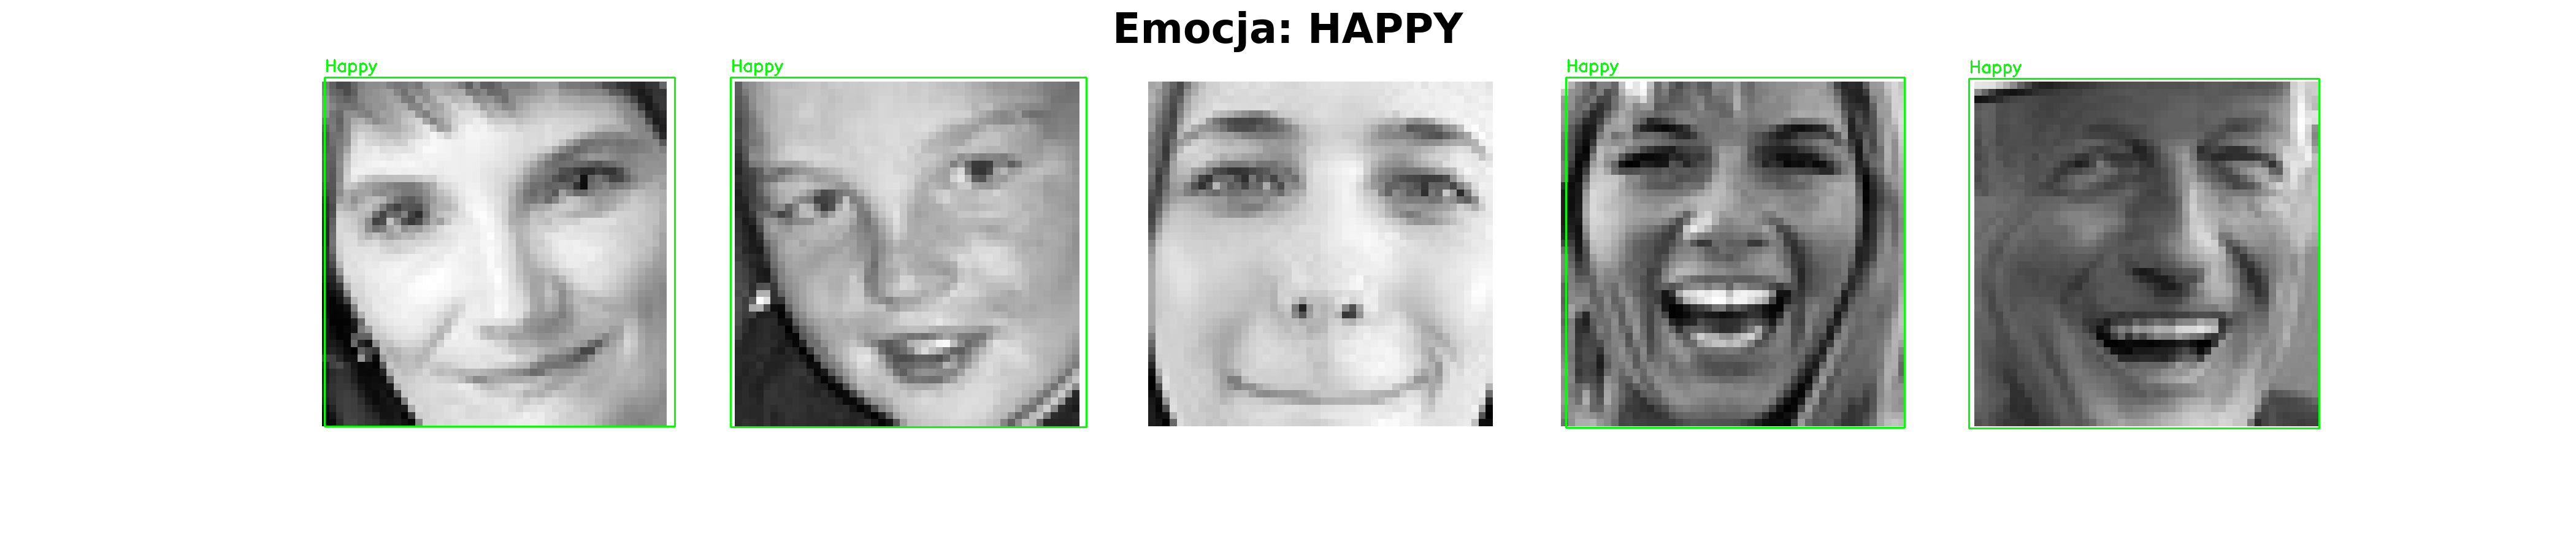

In [132]:
import cv2
import numpy as np

img = cv2.imread("viz_1_happy_samples.png")

results = yolo_model(img)

boxes = results[0].boxes.xyxy.cpu().numpy()

emotions = ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]

for box in boxes:

    x1, y1, x2, y2 = map(int, box)

    face = img[y1:y2, x1:x2]

    face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

    face_resized = cv2.resize(face_gray, (48,48))

    face_normalized = face_resized / 255.0

    face_input = np.expand_dims(face_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input)

    emotion_id = np.argmax(prediction)

    emotion = emotions[emotion_id]

    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
    cv2.putText(img,emotion,(x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,(0,255,0),2)

from google.colab.patches import cv2_imshow
cv2_imshow(img)

Znalezione pliki: ['./datasets/original/test/happy/PrivateTest_10077120.jpg', './datasets/original/test/happy/PrivateTest_10470092.jpg', './datasets/original/test/happy/PrivateTest_10513598.jpg', './datasets/original/test/happy/PrivateTest_10516065.jpg', './datasets/original/test/happy/PrivateTest_10613684.jpg']
./datasets/original/test/happy/PrivateTest_10077120.jpg -> Happy


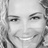

./datasets/original/test/happy/PrivateTest_10470092.jpg -> Surprise


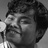

./datasets/original/test/happy/PrivateTest_10513598.jpg -> Happy


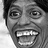

./datasets/original/test/happy/PrivateTest_10516065.jpg -> Happy


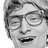

./datasets/original/test/happy/PrivateTest_10613684.jpg -> Happy


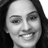

In [133]:
import glob

# Test klasyfikacji emocji dla obrazów wyciętych (pojedyncza twarz)
happy_files = sorted(glob.glob("./datasets/original/test/happy/*"))[:5]
print("Znalezione pliki:", happy_files)

for file_name in happy_files:
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0

    face_input = np.expand_dims(img_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    print(file_name, "->", emotion)
    cv2_imshow(img_resized)

In [134]:
emotions = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

In [135]:
import cv2
import numpy as np
import glob
from google.colab.patches import cv2_imshow

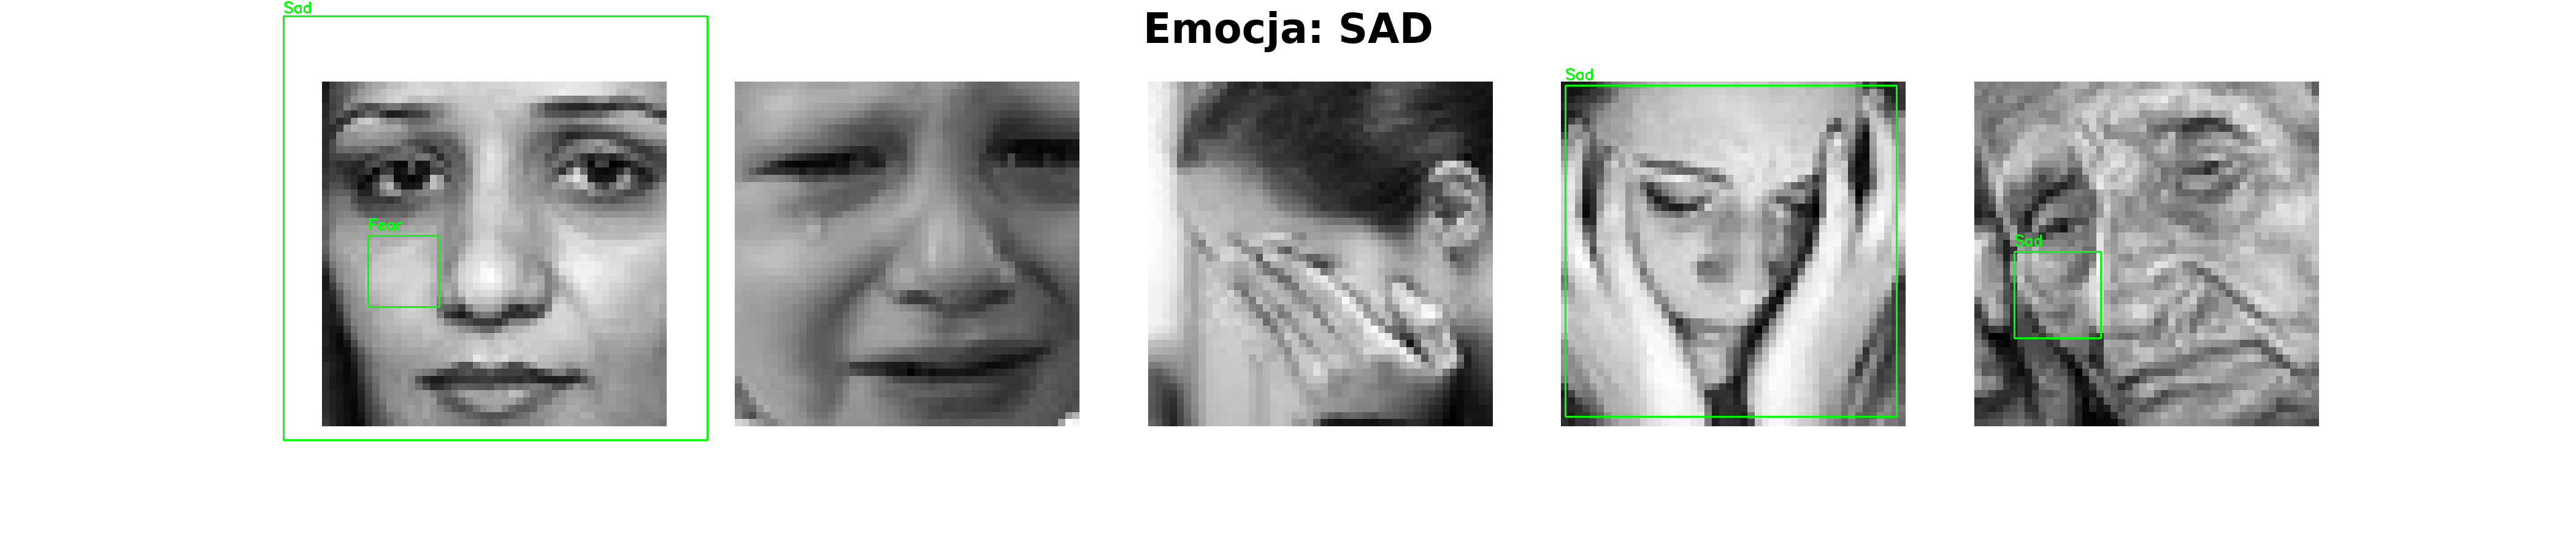

Liczba wykrytych twarzy: 4


In [136]:
img = cv2.imread("viz_1_sad_samples.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=4,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    face = gray[y:y+h, x:x+w]

    if face.size == 0:
        continue

    face_resized = cv2.resize(face, (48, 48))
    face_normalized = face_resized / 255.0

    face_input = np.expand_dims(face_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(
        img,
        emotion,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

cv2_imshow(img)
print("Liczba wykrytych twarzy:", len(faces))

Znalezione pliki: ['./datasets/original/test/sad/PrivateTest_10247676.jpg', './datasets/original/test/sad/PrivateTest_10455506.jpg', './datasets/original/test/sad/PrivateTest_10658656.jpg', './datasets/original/test/sad/PrivateTest_10702106.jpg', './datasets/original/test/sad/PrivateTest_10814167.jpg']
./datasets/original/test/sad/PrivateTest_10247676.jpg -> Neutral


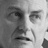

./datasets/original/test/sad/PrivateTest_10455506.jpg -> Sad


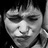

./datasets/original/test/sad/PrivateTest_10658656.jpg -> Fear


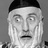

./datasets/original/test/sad/PrivateTest_10702106.jpg -> Sad


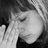

./datasets/original/test/sad/PrivateTest_10814167.jpg -> Fear


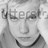

In [137]:
# Test klasyfikacji dla emocji SAD
sad_files = sorted(glob.glob("./datasets/original/test/sad/*"))[:5]
print("Znalezione pliki:", sad_files)

for file_name in sad_files:
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0

    face_input = np.expand_dims(img_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    print(file_name, "->", emotion)
    cv2_imshow(img_resized)

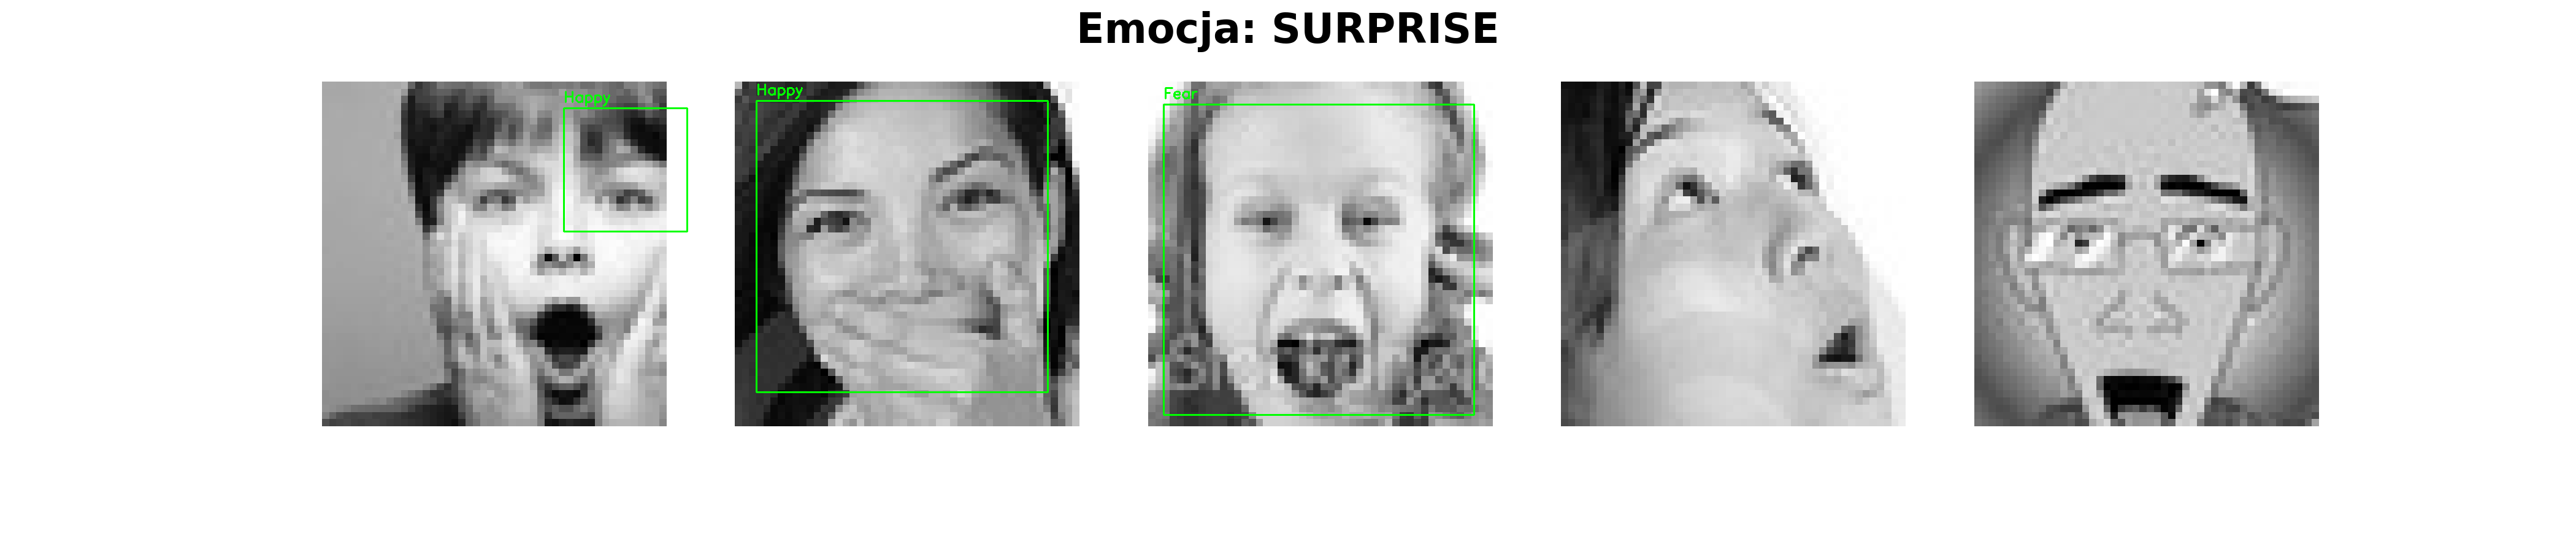

Liczba wykrytych twarzy: 3


In [138]:
img = cv2.imread("viz_1_surprise_samples.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=4,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    face = gray[y:y+h, x:x+w]

    if face.size == 0:
        continue

    face_resized = cv2.resize(face, (48, 48))
    face_normalized = face_resized / 255.0

    face_input = np.expand_dims(face_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(
        img,
        emotion,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

cv2_imshow(img)
print("Liczba wykrytych twarzy:", len(faces))

Znalezione pliki: ['./datasets/original/test/surprise/PrivateTest_10072988.jpg', './datasets/original/test/surprise/PrivateTest_10089743.jpg', './datasets/original/test/surprise/PrivateTest_104142.jpg', './datasets/original/test/surprise/PrivateTest_10427382.jpg', './datasets/original/test/surprise/PrivateTest_10712253.jpg']
./datasets/original/test/surprise/PrivateTest_10072988.jpg -> Surprise


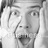

./datasets/original/test/surprise/PrivateTest_10089743.jpg -> Surprise


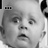

./datasets/original/test/surprise/PrivateTest_104142.jpg -> Sad


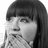

./datasets/original/test/surprise/PrivateTest_10427382.jpg -> Surprise


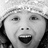

./datasets/original/test/surprise/PrivateTest_10712253.jpg -> Happy


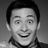

In [139]:
# Test klasyfikacji dla emocji SURPRISE
surprise_files = sorted(glob.glob("./datasets/original/test/surprise/*"))[:5]
print("Znalezione pliki:", surprise_files)

for file_name in surprise_files:
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0

    face_input = np.expand_dims(img_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    print(file_name, "->", emotion)
    cv2_imshow(img_resized)

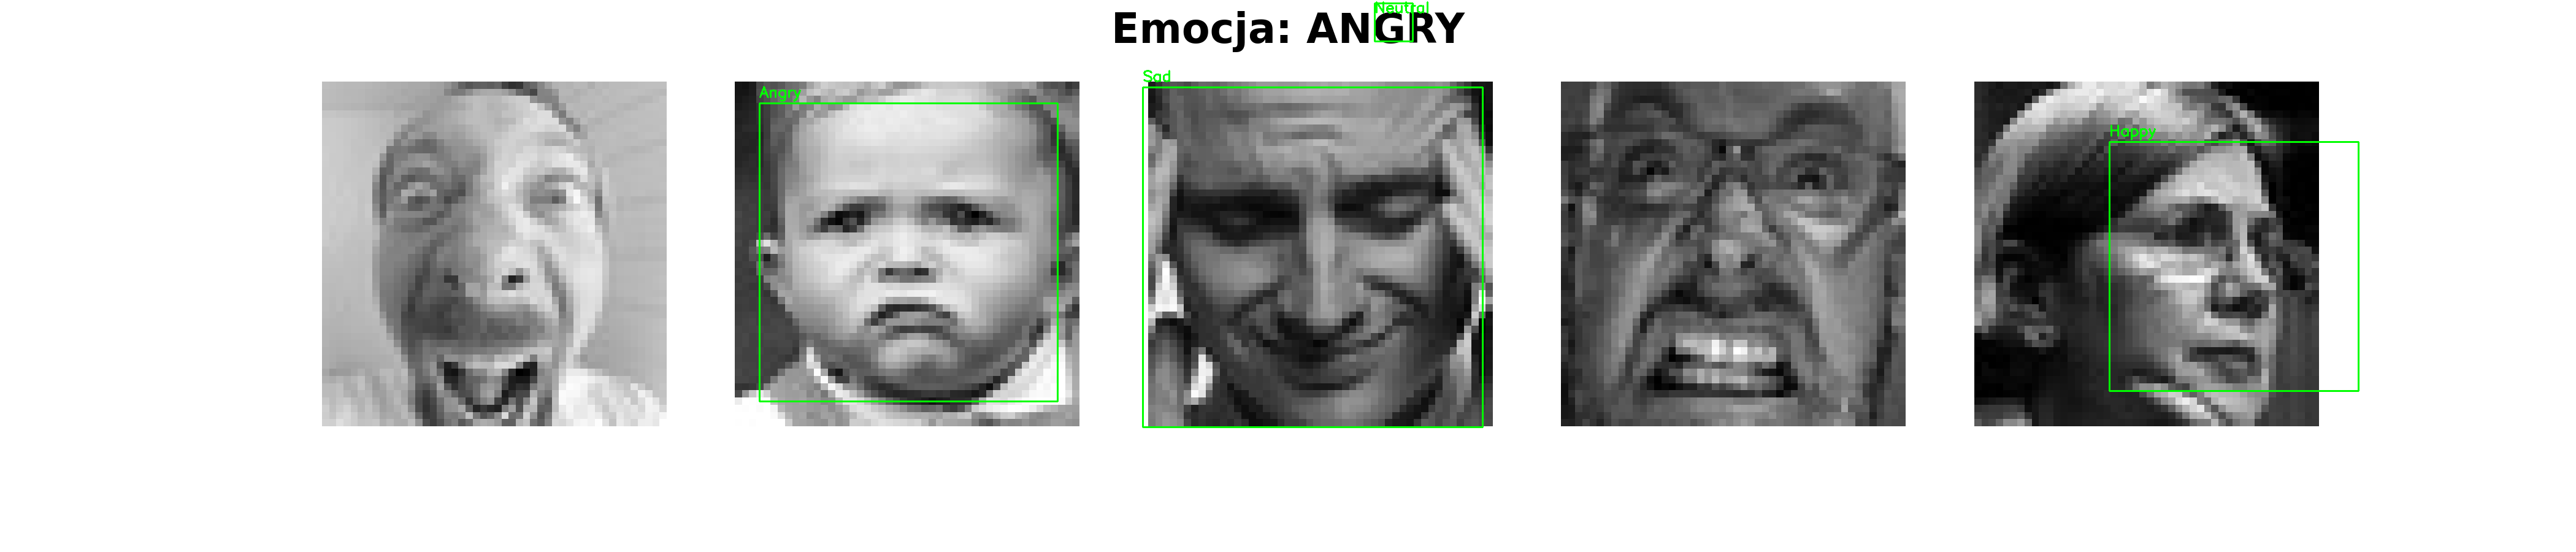

Liczba wykrytych twarzy: 4


In [140]:
img = cv2.imread("viz_1_angry_samples.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=4,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    face = gray[y:y+h, x:x+w]

    if face.size == 0:
        continue

    face_resized = cv2.resize(face, (48, 48))
    face_normalized = face_resized / 255.0

    face_input = np.expand_dims(face_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(
        img,
        emotion,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

cv2_imshow(img)
print("Liczba wykrytych twarzy:", len(faces))

Znalezione pliki: ['./datasets/original/test/angry/PrivateTest_10131363.jpg', './datasets/original/test/angry/PrivateTest_10304478.jpg', './datasets/original/test/angry/PrivateTest_1054527.jpg', './datasets/original/test/angry/PrivateTest_10590091.jpg', './datasets/original/test/angry/PrivateTest_1109992.jpg']
./datasets/original/test/angry/PrivateTest_10131363.jpg -> Angry


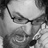

./datasets/original/test/angry/PrivateTest_10304478.jpg -> Fear


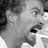

./datasets/original/test/angry/PrivateTest_1054527.jpg -> Sad


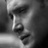

./datasets/original/test/angry/PrivateTest_10590091.jpg -> Sad


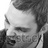

./datasets/original/test/angry/PrivateTest_1109992.jpg -> Angry


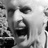

In [141]:
# Test klasyfikacji dla emocji ANGRY
angry_files = sorted(glob.glob("./datasets/original/test/angry/*"))[:5]
print("Znalezione pliki:", angry_files)

for file_name in angry_files:
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0

    face_input = np.expand_dims(img_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    print(file_name, "->", emotion)
    cv2_imshow(img_resized)

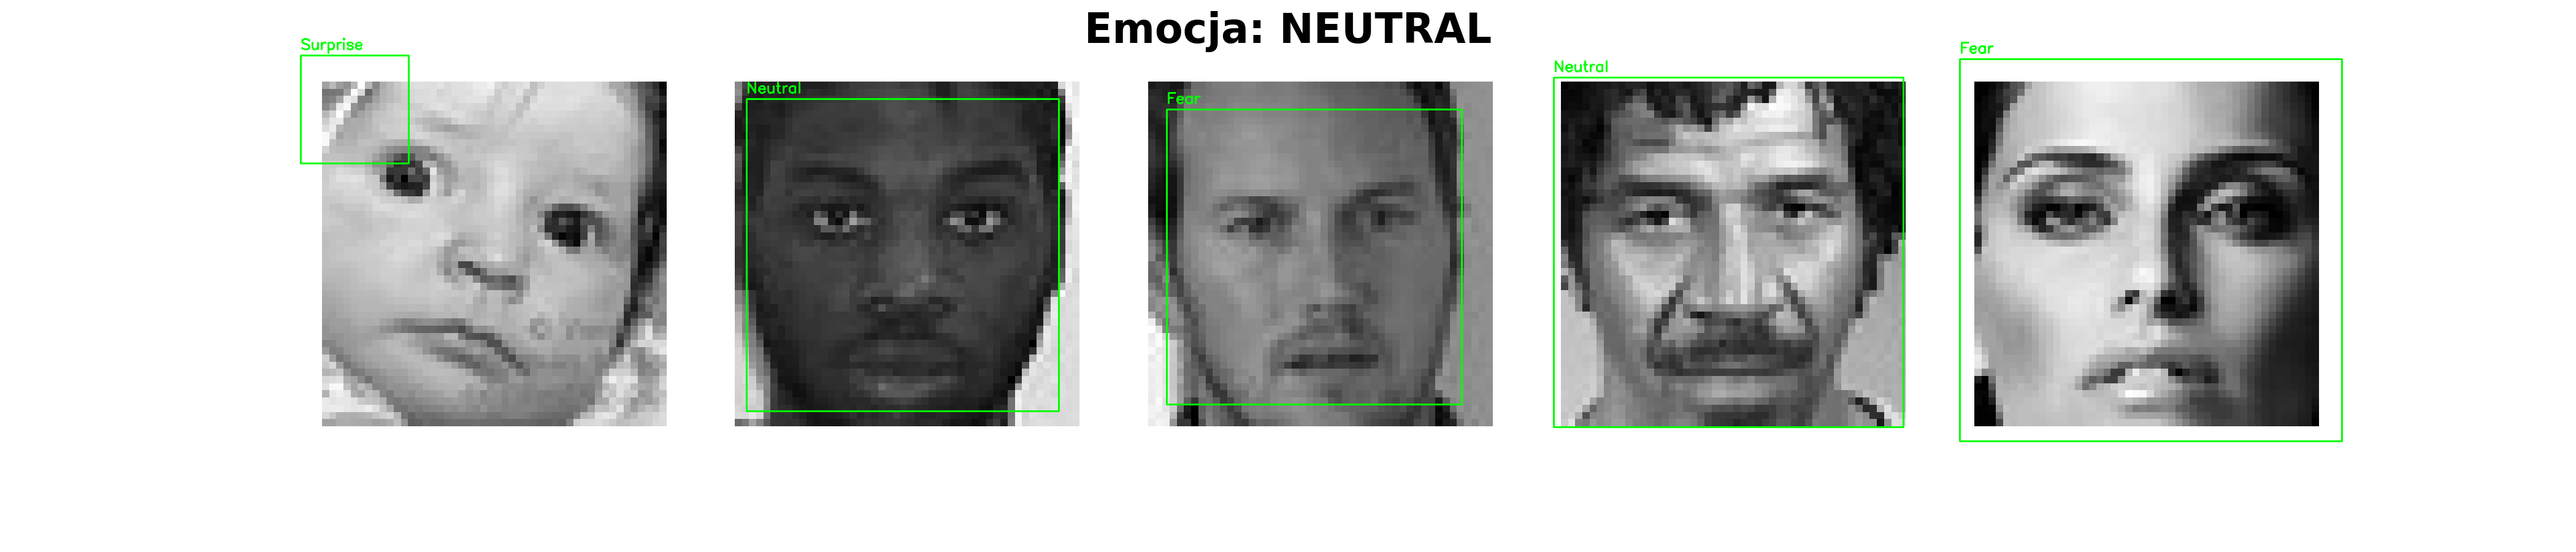

Liczba wykrytych twarzy: 5


In [142]:
img = cv2.imread("viz_1_neutral_samples.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=4,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    face = gray[y:y+h, x:x+w]

    if face.size == 0:
        continue

    face_resized = cv2.resize(face, (48, 48))
    face_normalized = face_resized / 255.0

    face_input = np.expand_dims(face_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(
        img,
        emotion,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

cv2_imshow(img)
print("Liczba wykrytych twarzy:", len(faces))

Znalezione pliki: ['./datasets/original/test/neutral/PrivateTest_10086748.jpg', './datasets/original/test/neutral/PrivateTest_10767287.jpg', './datasets/original/test/neutral/PrivateTest_11123843.jpg', './datasets/original/test/neutral/PrivateTest_11164800.jpg', './datasets/original/test/neutral/PrivateTest_11239107.jpg']
./datasets/original/test/neutral/PrivateTest_10086748.jpg -> Angry


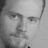

./datasets/original/test/neutral/PrivateTest_10767287.jpg -> Sad


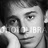

./datasets/original/test/neutral/PrivateTest_11123843.jpg -> Neutral


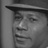

./datasets/original/test/neutral/PrivateTest_11164800.jpg -> Neutral


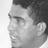

./datasets/original/test/neutral/PrivateTest_11239107.jpg -> Neutral


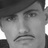

In [143]:
# Test klasyfikacji dla emocji NEUTRAL
neutral_files = sorted(glob.glob("./datasets/original/test/neutral/*"))[:5]
print("Znalezione pliki:", neutral_files)

for file_name in neutral_files:
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0

    face_input = np.expand_dims(img_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    print(file_name, "->", emotion)
    cv2_imshow(img_resized)

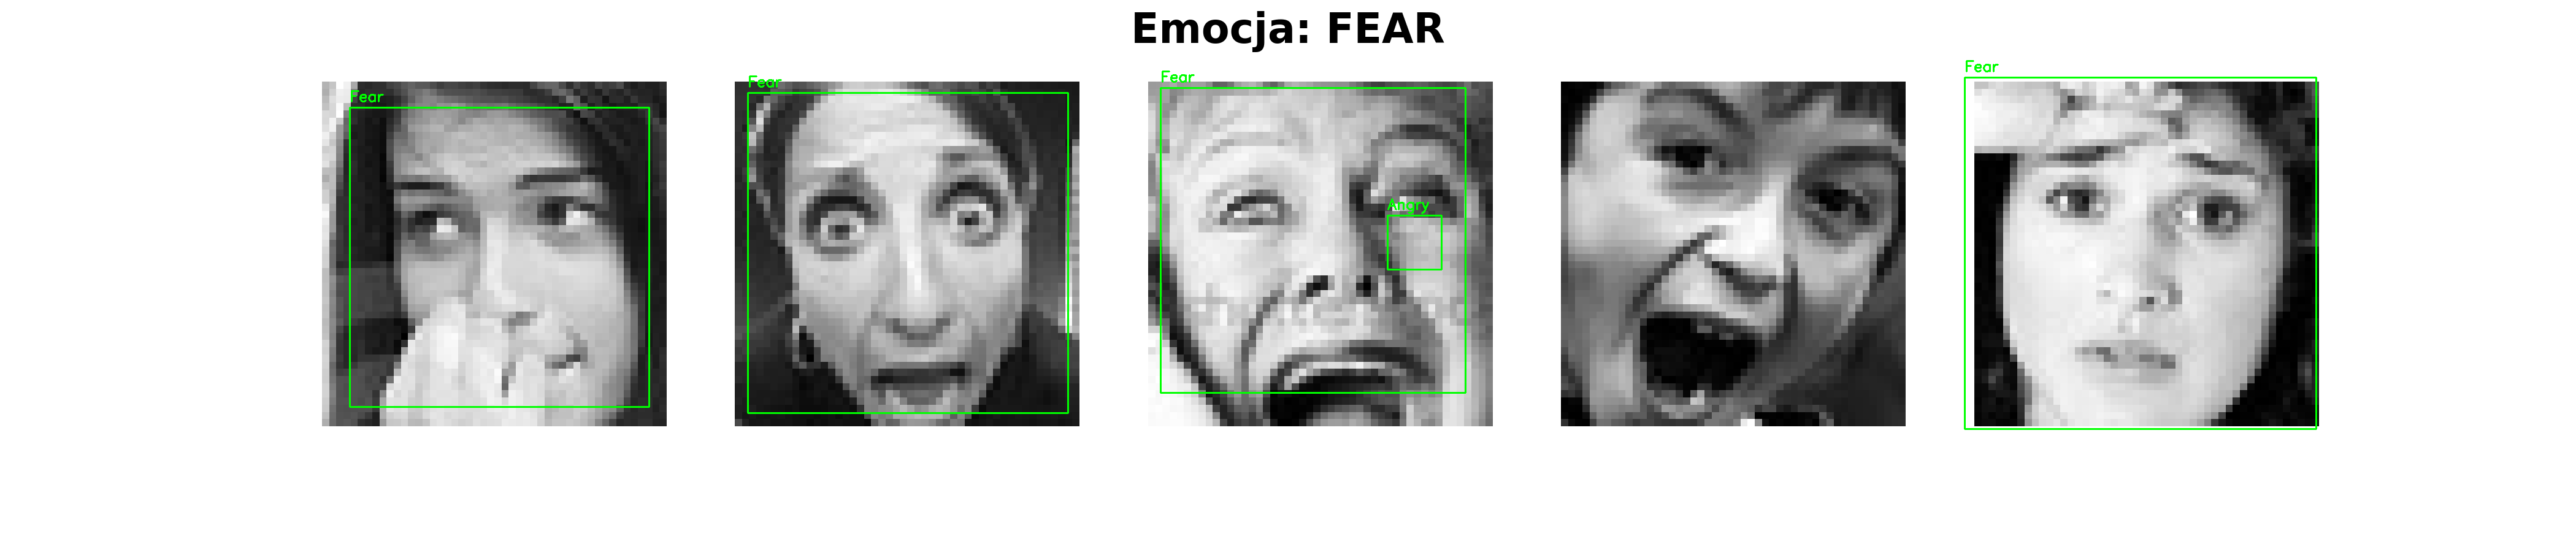

Liczba wykrytych twarzy: 5


In [144]:
img = cv2.imread("viz_1_fear_samples.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=4,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    face = gray[y:y+h, x:x+w]

    if face.size == 0:
        continue

    face_resized = cv2.resize(face, (48, 48))
    face_normalized = face_resized / 255.0

    face_input = np.expand_dims(face_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(
        img,
        emotion,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

cv2_imshow(img)
print("Liczba wykrytych twarzy:", len(faces))

Znalezione pliki: ['./datasets/original/test/fear/PrivateTest_10153550.jpg', './datasets/original/test/fear/PrivateTest_10254684.jpg', './datasets/original/test/fear/PrivateTest_10306709.jpg', './datasets/original/test/fear/PrivateTest_10555537.jpg', './datasets/original/test/fear/PrivateTest_10629254.jpg']
./datasets/original/test/fear/PrivateTest_10153550.jpg -> Fear


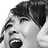

./datasets/original/test/fear/PrivateTest_10254684.jpg -> Angry


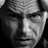

./datasets/original/test/fear/PrivateTest_10306709.jpg -> Happy


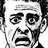

./datasets/original/test/fear/PrivateTest_10555537.jpg -> Angry


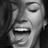

./datasets/original/test/fear/PrivateTest_10629254.jpg -> Sad


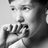

In [145]:
# Test klasyfikacji dla emocji FEAR
fear_files = sorted(glob.glob("./datasets/original/test/fear/*"))[:5]
print("Znalezione pliki:", fear_files)

for file_name in fear_files:
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0

    face_input = np.expand_dims(img_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    print(file_name, "->", emotion)
    cv2_imshow(img_resized)

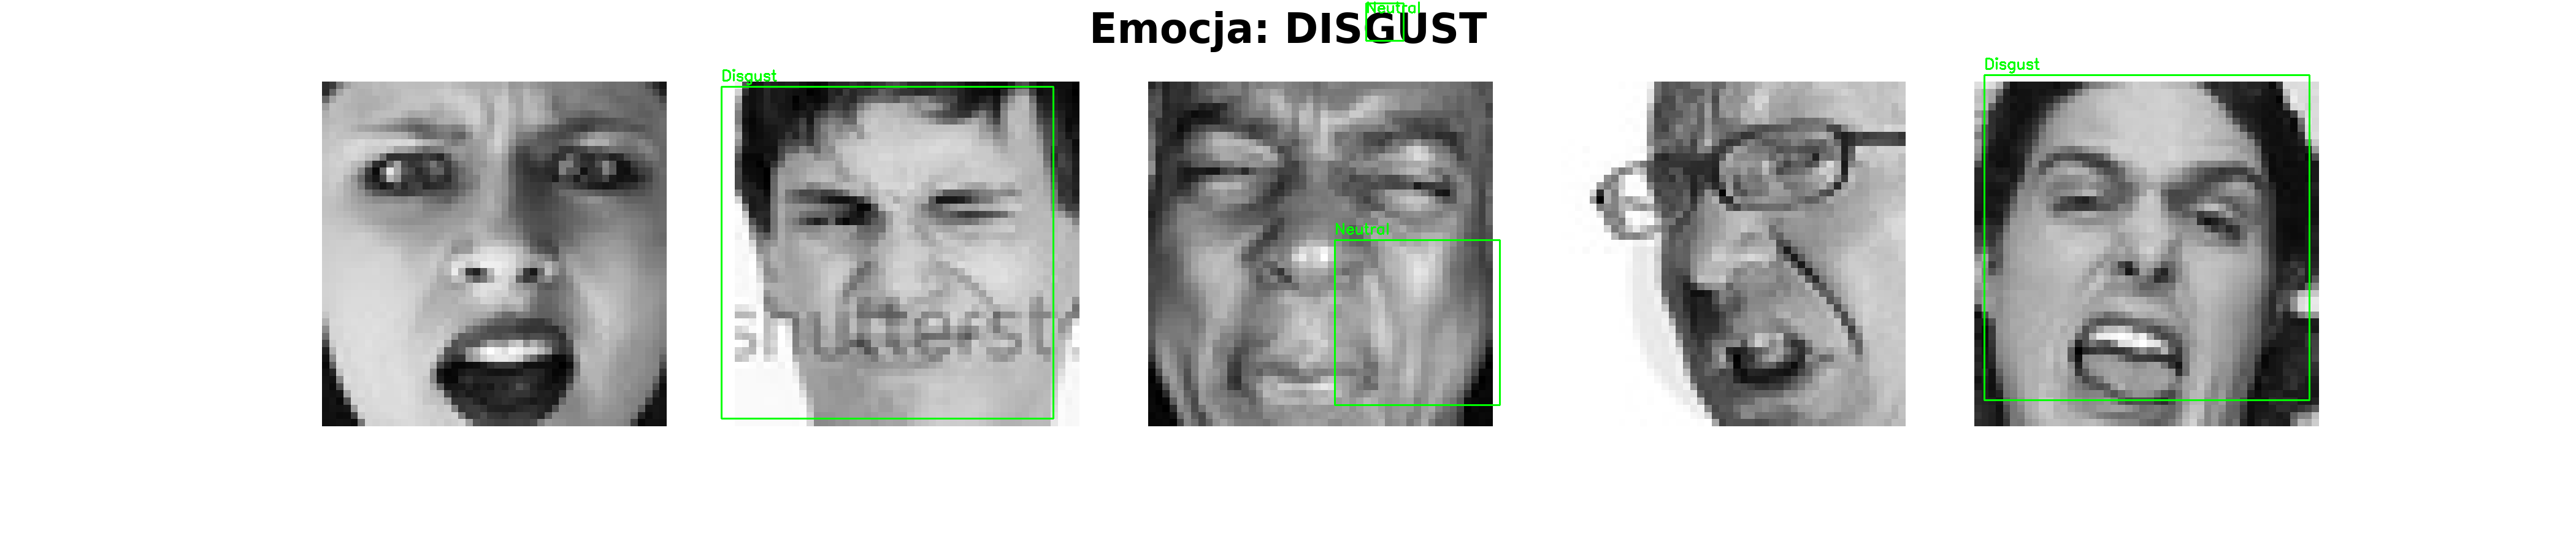

Liczba wykrytych twarzy: 4


In [146]:
img = cv2.imread("viz_1_disgust_samples.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=4,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    face = gray[y:y+h, x:x+w]

    if face.size == 0:
        continue

    face_resized = cv2.resize(face, (48, 48))
    face_normalized = face_resized / 255.0

    face_input = np.expand_dims(face_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(
        img,
        emotion,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

cv2_imshow(img)
print("Liczba wykrytych twarzy:", len(faces))

Znalezione pliki: ['./datasets/original/test/disgust/PrivateTest_11895083.jpg', './datasets/original/test/disgust/PrivateTest_19671520.jpg', './datasets/original/test/disgust/PrivateTest_21629266.jpg', './datasets/original/test/disgust/PrivateTest_22382996.jpg', './datasets/original/test/disgust/PrivateTest_26306320.jpg']
./datasets/original/test/disgust/PrivateTest_11895083.jpg -> Surprise


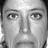

./datasets/original/test/disgust/PrivateTest_19671520.jpg -> Happy


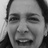

./datasets/original/test/disgust/PrivateTest_21629266.jpg -> Sad


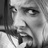

./datasets/original/test/disgust/PrivateTest_22382996.jpg -> Disgust


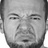

./datasets/original/test/disgust/PrivateTest_26306320.jpg -> Disgust


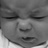

In [147]:
# Test klasyfikacji dla emocji DISGUST
disgust_files = sorted(glob.glob("./datasets/original/test/disgust/*"))[:5]
print("Znalezione pliki:", disgust_files)

for file_name in disgust_files:
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0

    face_input = np.expand_dims(img_normalized, axis=0)
    face_input = np.expand_dims(face_input, axis=-1)

    prediction = emotion_model.predict(face_input, verbose=0)
    emotion_id = np.argmax(prediction)
    emotion = emotions[emotion_id]

    print(file_name, "->", emotion)
    cv2_imshow(img_resized)